Best parameters: {'alpha': 0.1, 'l1_ratio': 0.3}
Best negative MSE score: -24.72854706593653

Model Performance:
Mean Squared Error: 24.216092080397036
R2 Score: 0.6697825880950993


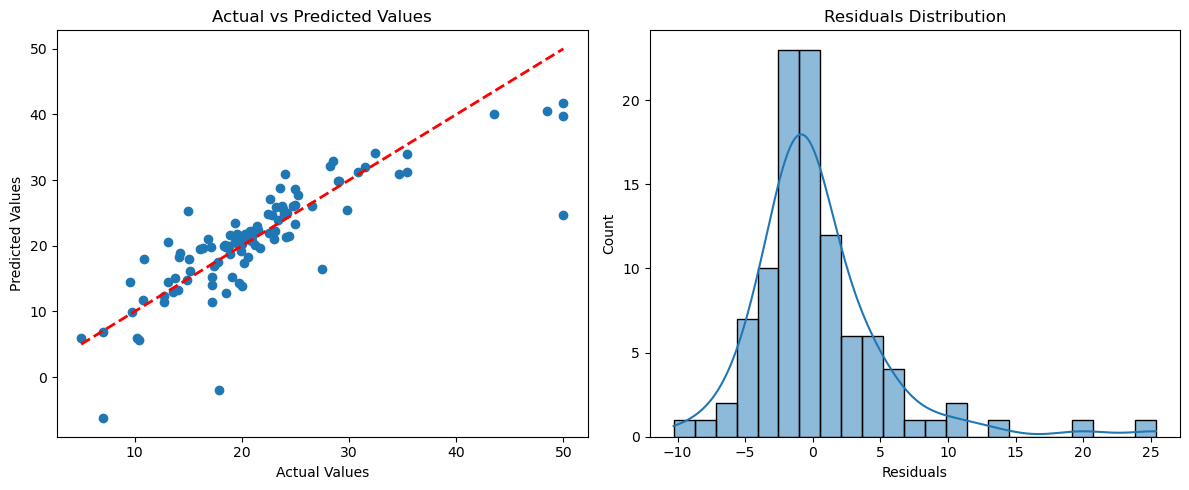

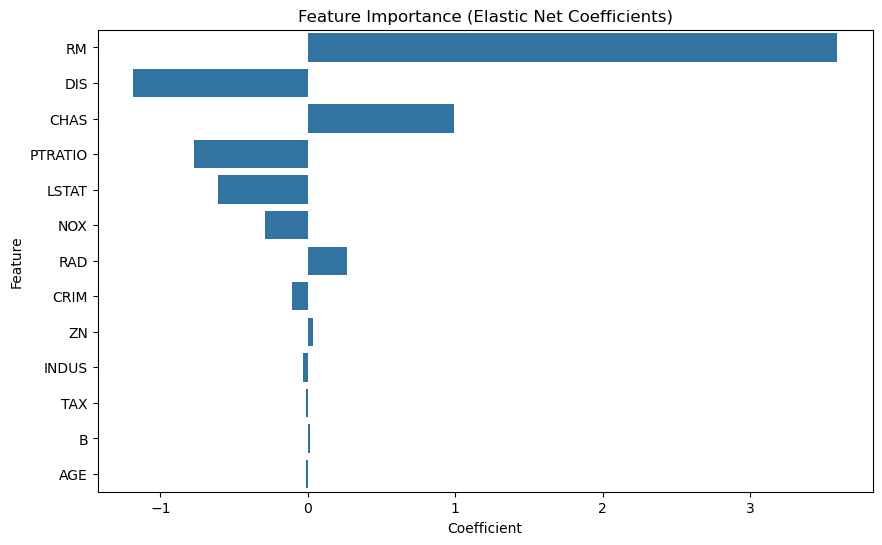

In [1]:
#Step 1: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

#Step 2: Load and prepare the Boston Housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Combine the data properly
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
           'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :3]])
boston_df = pd.DataFrame(data, columns=columns)

#Step 3: Separate features and target
X = boston_df.drop('MEDV', axis=1)
y = boston_df['MEDV']

#Step 4: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 5: Create and train Elastic Net model with GridSearchCV
# Define parameter grid
param_grid = {
    'alpha': [0.1, 0.3, 0.5, 0.7, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Create Elastic Net model
elastic_net = ElasticNet(max_iter=1000)

# Perform GridSearchCV
grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

#Step 6: Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best negative MSE score:", grid_search.best_score_)

#Step 7: Make predictions
y_pred = grid_search.predict(X_test)

#Step 8: Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

#Step 9: Visualize results
plt.figure(figsize=(12, 5))

# Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

# Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()

#Step 10: Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': grid_search.best_estimator_.coef_
})
feature_importance = feature_importance.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance (Elastic Net Coefficients)')
plt.show()


Ridge (L2) Results:
MSE: 0.0182
R2: 0.9964

Lasso (L1) Results:
MSE: 4.5334
R2: 0.1171

Elastic Net (L1 + L2) Results:
MSE: 3.4197
R2: 0.3340


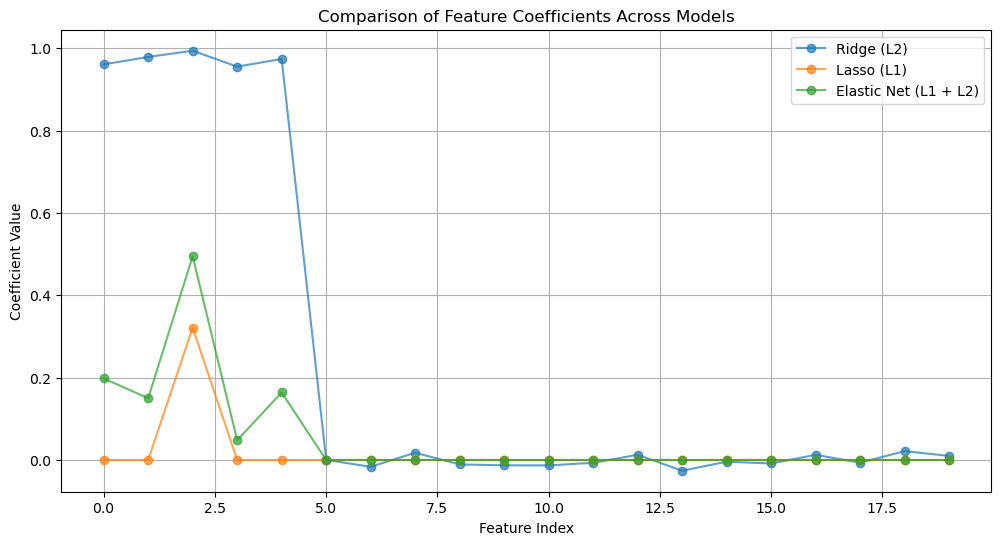

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.randn(100, 20)
y = np.sum(X[:, :5], axis=1) + np.random.randn(100) * 0.1  # Only first 5 features are relevant

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Train models
models = {
    'Ridge (L2)': ridge,
    'Lasso (L1)': lasso,
    'Elastic Net (L1 + L2)': elastic
}

results = {}
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MSE': mse,
        'R2': r2,
        'Coefficients': model.coef_
    }

    print(f"\n{name} Results:")
    print(f"MSE: {mse:.4f}")
    print(f"R2: {r2:.4f}")

# Visualize coefficients
plt.figure(figsize=(12, 6))
x = np.arange(X.shape[1])

for name, result in results.items():
    plt.plot(x, result['Coefficients'], label=name, marker='o', alpha=0.7)

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Feature Coefficients Across Models')
plt.legend()
plt.grid(True)
plt.show()